# Week 5: Optimize Machine Learning Models with Hyperparameter Optimization

In [1]:
import pandas as pd

df = pd.read_csv('heart_failure_clinical_records_dataset.csv')
df.drop(columns=['time'], inplace=True)
df_features = df.iloc[:, :-1]
df_target = df['DEATH_EVENT']

X = df_features
y = df_target


## Create train and test sets


In [2]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=21)

## Normalize Data

In [3]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Hyperparameter Optimization

### Basic Approach

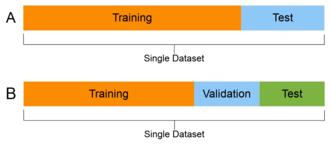

In [4]:
from IPython.display import Image

Image(filename='images/xTmSM.png')

In [5]:
import warnings

warnings.filterwarnings("ignore") # suppress all warnings globally

X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=21)

# Create validation set
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.1, random_state=21, stratify=y_train_full)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

from sklearn.ensemble import RandomForestClassifier

n_estimators_values = [20, 50, 100, 150, 200]
max_depth_values = [5, 10, 13]

best_score = 0
best_params = None

print("Hyperparameter tuning results:\n")

for n_estimators in n_estimators_values:
    for max_depth in max_depth_values:
        model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            random_state=42
        )

        model.fit(X_train, y_train)
        y_val_pred = model.predict(X_val)
        val_accuracy = accuracy_score(y_val, y_val_pred)

        print(
            f"n_estimators = {n_estimators:<3} | "
            f"max_depth = {str(max_depth):<5} | "
            f"Validation Accuracy = {val_accuracy:.4f}"
        )

        if val_accuracy > best_score:
            best_score = val_accuracy
            best_params = {
                "n_estimators": n_estimators,
                "max_depth": max_depth
            }

print(f"\nBest Hyperparameters: {best_params}")
print(f"Best Validation Accuracy = {best_score:.4f}")

final_model = RandomForestClassifier(
    n_estimators=best_params["n_estimators"],
    max_depth=best_params["max_depth"],
    random_state=42
)

final_model.fit(X_train_full, y_train_full)

y_test_pred = final_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"\nFinal Test Accuracy = {test_accuracy:.4f}")

Hyperparameter tuning results:

n_estimators = 20  | max_depth = 5     | Validation Accuracy = 0.8571
n_estimators = 20  | max_depth = 10    | Validation Accuracy = 0.8095
n_estimators = 20  | max_depth = 13    | Validation Accuracy = 0.8571
n_estimators = 50  | max_depth = 5     | Validation Accuracy = 0.8571
n_estimators = 50  | max_depth = 10    | Validation Accuracy = 0.9048
n_estimators = 50  | max_depth = 13    | Validation Accuracy = 0.9048
n_estimators = 100 | max_depth = 5     | Validation Accuracy = 0.8571
n_estimators = 100 | max_depth = 10    | Validation Accuracy = 0.9048
n_estimators = 100 | max_depth = 13    | Validation Accuracy = 0.8571
n_estimators = 150 | max_depth = 5     | Validation Accuracy = 0.8571
n_estimators = 150 | max_depth = 10    | Validation Accuracy = 0.8095
n_estimators = 150 | max_depth = 13    | Validation Accuracy = 0.8571
n_estimators = 200 | max_depth = 5     | Validation Accuracy = 0.8571
n_estimators = 200 | max_depth = 10    | Validation Accura

#### GridSearch CV

Python has a package that can automatically do this optimization for you

In [6]:
from sklearn.model_selection import GridSearchCV

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=21)

scaler = StandardScaler()
X_train_n = scaler.fit_transform(X_train)
X_test_n = scaler.transform(X_test)

model = RandomForestClassifier(random_state=21)

param_grid = {
    'n_estimators': [20, 50, 100, 150, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 7, 10, 13],
    'max_features': ['sqrt', 'log2']
}

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_n, y_train)

print(f"\nBest Hyperparamers: {grid.best_params_}")
print(f"\nBest Cross-Validation Accuracy: {grid.best_score_}")

y_test_pred = grid.predict(X_test_n)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"\nFinal Test Accuracy: {test_accuracy}")

Fitting 5 folds for each of 150 candidates, totalling 750 fits

Best Hyperparamers: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 50}

Best Cross-Validation Accuracy: 0.7652729384436701

Final Test Accuracy: 0.7333333333333333


### Optuna: Modern Hyperparameter Optimization

Optuna is a lightweight framework for advanced hyperparameter optimization. Unlike GridSearchCV which tests all combinations, Optuna intelligently searches the parameter space.

Key strategies:
- Random Search: Random sampling from search space
- Bayesian Optimization (TPE): Learn from previous trials to propose better parameters

Benefits:
- Much faster than GridSearch (especially with expensive models)
- Handle continuous, discrete, and categorical parameters naturally
- Can prune unpromising trials early
- State-of-the-art for real-world problems

### Random Search with Optuna

- Sample parameters uniformly at random
- Simple but effective (just randomly try different combinations and pick the best)

In [7]:
import optuna
from optuna.samplers import RandomSampler
from sklearn.model_selection import cross_val_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=21)

scaler = StandardScaler()
X_train_n = scaler.fit_transform(X_train)
X_test_n = scaler.transform(X_test)

def objective_random(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 10, 200),
        'max_depth': trial.suggest_int('max_depth', 3, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2'])
    }
    model = RandomForestClassifier(**params, random_state=21)
    scores = cross_val_score(model, X_train_n, y_train, cv=5, scoring='accuracy')
    return scores.mean()

study_random = optuna.create_study(direction='maximize', sampler=RandomSampler(seed=21))
study_random.optimize(objective_random, n_trials=50, show_progress_bar=True)

print(f"Best Validation Accuracy: {study_random.best_value:.4f}")
print(f"Best Params: {study_random.best_params}\n")

best_model_random = RandomForestClassifier(**study_random.best_params, random_state=21)
best_model_random.fit(X_train_n, y_train)
test_acc_random = accuracy_score(y_test, best_model_random.predict(X_test_n))
print(f"Test accuracy: {test_acc_random:.4f}")

[I 2026-08-14 21:15:54,411] A new study created in memory with name: no-name-2ba1522f-2b8e-4ffa-841e-33e0b2ddaede


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-08-14 21:15:54,465] Trial 0 finished with value: 0.7702671312427409 and parameters: {'n_estimators': 19, 'max_depth': 11, 'min_samples_split': 15, 'max_features': 'log2'}. Best is trial 0 with value: 0.7702671312427409.
[I 2026-08-14 21:15:54,515] Trial 1 finished with value: 0.7701509872241579 and parameters: {'n_estimators': 19, 'max_depth': 11, 'min_samples_split': 14, 'max_features': 'log2'}. Best is trial 0 with value: 0.7702671312427409.
[I 2026-08-14 21:15:54,575] Trial 2 finished with value: 0.7507549361207898 and parameters: {'n_estimators': 23, 'max_depth': 27, 'min_samples_split': 4, 'max_features': 'log2'}. Best is trial 0 with value: 0.7702671312427409.
[I 2026-08-14 21:15:54,961] Trial 3 finished with value: 0.7556329849012775 and parameters: {'n_estimators': 174, 'max_depth': 24, 'min_samples_split': 20, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.7702671312427409.
[I 2026-08-14 21:15:55,165] Trial 4 finished with value: 0.746109175377468 and parameter

### Bayesian Optimization (TPE Sampler)

Bayesian Optimization is smarter: It builds a probability model of the objective function and uses it to propose promising parameter combinations. Tree-structured Parzen Estimator (TPE) is the algorithm that makes this work.

Key insight: After each trial, we learn something about which parameters work better so the next trial is more likely to be good.

In [8]:
from optuna.samplers import TPESampler

def objective_bayesian(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 10, 200),
        'max_depth': trial.suggest_int('max_depth', 3, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2'])
    }
    model = RandomForestClassifier(**params, random_state=21)
    scores = cross_val_score(model, X_train_n, y_train, cv=5, scoring='accuracy')
    return scores.mean()

study_bayesian = optuna.create_study(direction='maximize', sampler=TPESampler(seed=21))
study_bayesian.optimize(objective_bayesian, n_trials=50, show_progress_bar=True)

print(f"Best Validation Accuracy: {study_bayesian.best_value:.4f}")
print(f"Best Params: {study_bayesian.best_params}\n")

best_model_bayesian = RandomForestClassifier(**study_bayesian.best_params, random_state=21)
best_model_bayesian.fit(X_train_n, y_train)
test_acc_bayesian = accuracy_score(y_test, best_model_bayesian.predict(X_test_n))
print(f"Test Accuracy: {test_accuracy:.4f}")

[I 2026-08-14 21:16:07,041] A new study created in memory with name: no-name-d5b9ddb5-f6b8-49ab-84f7-1f852c7cfc38


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-08-14 21:16:07,112] Trial 0 finished with value: 0.7702671312427409 and parameters: {'n_estimators': 19, 'max_depth': 11, 'min_samples_split': 15, 'max_features': 'log2'}. Best is trial 0 with value: 0.7702671312427409.
[I 2026-08-14 21:16:07,161] Trial 1 finished with value: 0.7701509872241579 and parameters: {'n_estimators': 19, 'max_depth': 11, 'min_samples_split': 14, 'max_features': 'log2'}. Best is trial 0 with value: 0.7702671312427409.
[I 2026-08-14 21:16:07,221] Trial 2 finished with value: 0.7507549361207898 and parameters: {'n_estimators': 23, 'max_depth': 27, 'min_samples_split': 4, 'max_features': 'log2'}. Best is trial 0 with value: 0.7702671312427409.
[I 2026-08-14 21:16:07,614] Trial 3 finished with value: 0.7556329849012775 and parameters: {'n_estimators': 174, 'max_depth': 24, 'min_samples_split': 20, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.7702671312427409.
[I 2026-08-14 21:16:07,826] Trial 4 finished with value: 0.746109175377468 and parameter

## Quick Comparison

| | GridSearchCV | Random Search | Bayesian (TPE) |
|---|---|---|---|
| Speed | Slow (test all) | Medium | Fast (learn) |
| Evaluations | All combinations | Fixed budget | Fixed budget |
| Best For | Small grids | Simple & parallel | Real projects |
| Pros | Exhaustive | Simple | Most efficient |
| Cons | Expensive | No learning | Slightly complex |

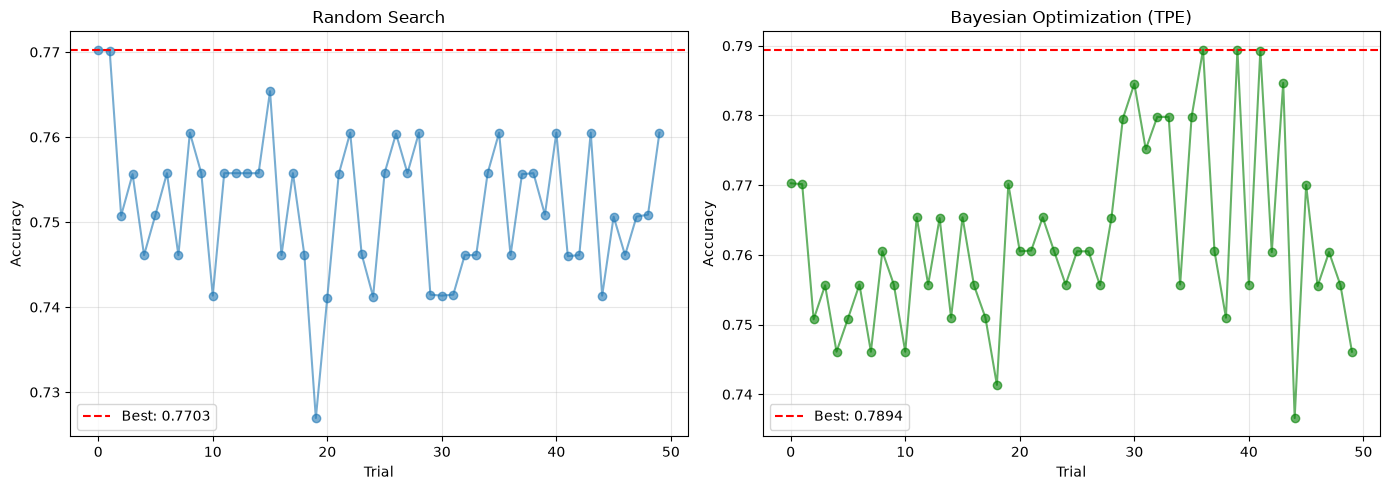

--------------------------------------------------
Method               Val Acc         Test Acc       
--------------------------------------------------
Random Search        0.7703          0.7556         
Bayesian (TPE)       0.7894          0.7889         
--------------------------------------------------


In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

random_vals = [t.value for t in study_random.trials]
bayesian_vals = [t.value for t in study_bayesian.trials]

axes[0].plot(random_vals, 'o-', alpha=0.6)
axes[0].axhline(y=study_random.best_value, color='r', linestyle='--', label=f'Best: {study_random.best_value:.4f}')
axes[0].set_title('Random Search')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(bayesian_vals, 'o-', alpha=0.6, color='green')
axes[1].axhline(y=study_bayesian.best_value, color='r', linestyle='--', label=f'Best: {study_bayesian.best_value:.4f}')
axes[1].set_title('Bayesian Optimization (TPE)')
axes[1].set_xlabel('Trial')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("-"*50)
print(f"{'Method':<20} {'Val Acc':<15} {'Test Acc':<15}")
print("-"*50)
print(f"{'Random Search':<20} {study_random.best_value:<15.4f} {test_acc_random:<15.4f}")
print(f"{'Bayesian (TPE)':<20} {study_bayesian.best_value:<15.4f} {test_acc_bayesian:<15.4f}")
print("-"*50)

## When to Use Each Approach

GridSearchCV: Small, well-defined parameter grid

Random Search: Large search space, easy parallelization needed

Bayesian Optimization (Optuna):
- Most real projects
- Expensive objective function (long model training)
- Mix of continuous and discrete parameters
- Want best results with reasonable compute
- Working on actual problems, not toy examples

## Bonus: Pruning (Early Stopping)

If a model looks bad halfway through training, why keep going? Pruning lets Optuna stop unpromising trials early, which saves lots of time, especially with deep learning models.

Example:

```python
def objective_with_pruning(trial):
    for epoch in range(100):
        acc = train_epoch()
        trial.report(acc, epoch) # report progress

        if trial.should_prune(): # stop if not promising
            raise optuna.TrialPruned()
    
    return final_accuracy
```